## Podsumowanie — Model Base (features.csv)

- **Najlepszy model:** Random Forest (CV R² = -0.065)
- **Główne cechy:** avg_hh_size, avg_building_area, commercial_count, pop_households
- **Cechy bezużyteczne:** większość POI, peak_morning_signals, competitor_count
- **Ograniczenie:** 50 próbek — zbyt mało dla wiarygodnego modelu ML

In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import os

load_dotenv()

PROCESSED_DIR = r"C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\procced"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

print("✅ Biblioteki załadowane")

c:\Users\slast\miniconda3\envs\GEO\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Biblioteki załadowane


In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'features.csv'))

feature_cols = [c for c in df.columns 
                if c not in ['location_id', 'lat', 'lng', 'monthly_revenue']]

X = df[feature_cols]
y = df['monthly_revenue']

print(f"✅ Dataset: {df.shape[0]} lokalizacji × {len(feature_cols)} cech")
print(f"Target — monthly_revenue:")
print(f"  min:    {y.min():>10,.0f} PLN")
print(f"  mediana:{y.median():>10,.0f} PLN")
print(f"  max:    {y.max():>10,.0f} PLN")

✅ Dataset: 50 lokalizacji × 23 cech
Target — monthly_revenue:
  min:        50,000 PLN
  mediana:   260,957 PLN
  max:       623,866 PLN


In [3]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    'Ridge':         Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=5, random_state=42),
    'XGBoost':       xgb.XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.1, subsample=0.8, colsample_bytree=0.5, reg_alpha=1.0, reg_lambda=2.0, random_state=42, verbosity=0),
    'SVR':           Pipeline([('scaler', StandardScaler()), ('model', SVR(C=100, epsilon=0.1))])
}

results = []
for name, model in models.items():
    cv_r2   = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_rmse = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    results.append({
        'Model':     name,
        'CV R²':     cv_r2.mean().round(3),
        'CV R² std': cv_r2.std().round(3),
        'CV RMSE':   (-cv_rmse.mean()).round(0)
    })

df_results = pd.DataFrame(results).sort_values('CV R²', ascending=False)
print("✅ Porównanie modeli (5-fold CV):")
display(df_results)

✅ Porównanie modeli (5-fold CV):


,Model,CV R²,CV R² std,CV RMSE
1,Random Forest,-0.065,0.220,103275.0
3,SVR,-0.109,0.127,106329.0
2,XGBoost,-0.175,0.273,106367.0
0,Ridge,-0.315,0.297,112447.0


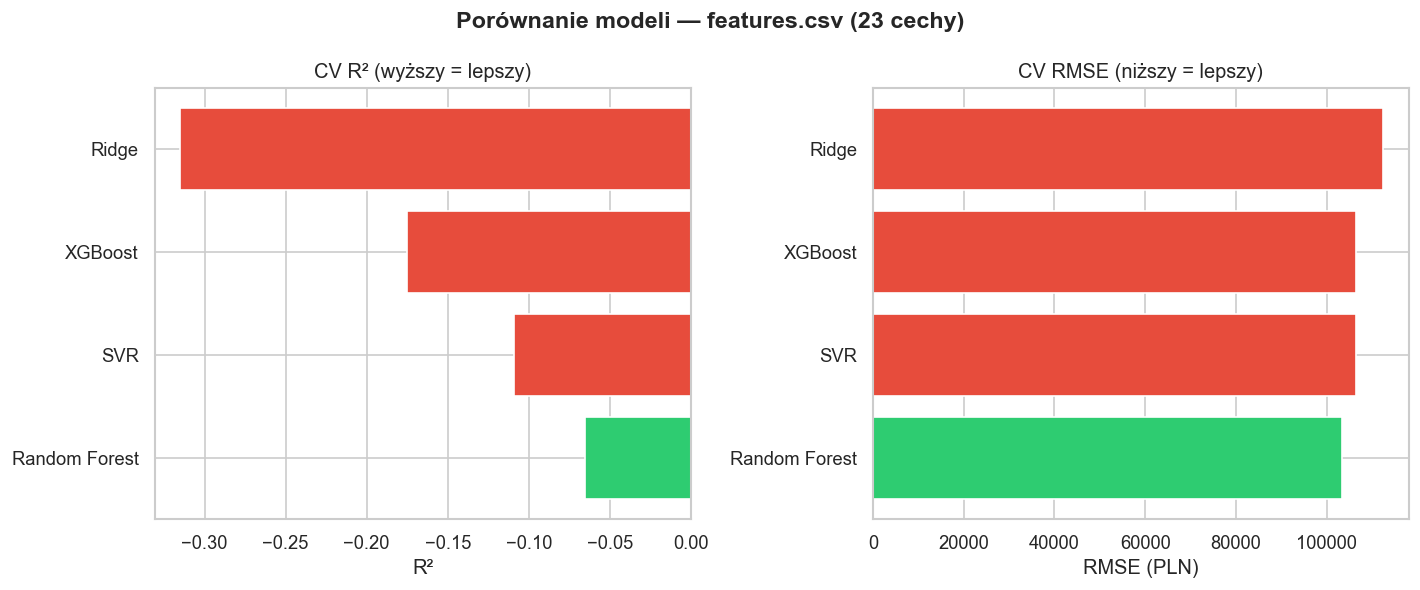

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CV R²
colors = ['#2ecc71' if v == df_results['CV R²'].max() else '#e74c3c' 
          for v in df_results['CV R²']]
axes[0].barh(df_results['Model'], df_results['CV R²'], color=colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('CV R² (wyższy = lepszy)')
axes[0].set_xlabel('R²')

# CV RMSE
colors2 = ['#2ecc71' if v == df_results['CV RMSE'].min() else '#e74c3c'
           for v in df_results['CV RMSE']]
axes[1].barh(df_results['Model'], df_results['CV RMSE'], color=colors2)
axes[1].set_title('CV RMSE (niższy = lepszy)')
axes[1].set_xlabel('RMSE (PLN)')

plt.suptitle('Porównanie modeli — features.csv (23 cechy)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Log transformacja targetu — ma sens bo:

Przychód ma rozkład prawostronnie skośny (widzieliśmy to w EDA)
Log "ściska" outliery i normalizuje rozkład
Modele liniowe szczególnie lubią normalny rozkład targetu

Standaryzacja/normalizacja — Ridge i SVR już mają StandardScaler w pipeline. Random Forest i XGBoost nie potrzebują — są odporne na skalę cech.
Sprawdźmy wszystkie trzy warianty:

In [5]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Target oryginalny vs log
y_log = np.log1p(y)

models = {
    'Ridge':         Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))]),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=5, random_state=42),
    'XGBoost':       xgb.XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.1, subsample=0.8, colsample_bytree=0.5, reg_alpha=1.0, reg_lambda=2.0, random_state=42, verbosity=0),
    'SVR':           Pipeline([('scaler', StandardScaler()), ('model', SVR(C=100, epsilon=0.1))])
}

results = []
for name, model in models.items():
    # Oryginalny target
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
    results.append({'Model': name, 'Target': 'original', 'CV R²': cv_r2.mean().round(3)})
    
    # Log target
    cv_r2_log = cross_val_score(model, X, y_log, cv=5, scoring='r2')
    results.append({'Model': name, 'Target': 'log', 'CV R²': cv_r2_log.mean().round(3)})

df_results = pd.DataFrame(results)
df_pivot = df_results.pivot(index='Model', columns='Target', values='CV R²').round(3)
df_pivot['poprawa'] = (df_pivot['log'] - df_pivot['original']).round(3)
df_pivot = df_pivot.sort_values('log', ascending=False)

print("✅ Porównanie — oryginalny target vs log(target):")
display(df_pivot)

✅ Porównanie — oryginalny target vs log(target):


Target,log,original,poprawa
Model,,,
Random Forest,-0.109,-0.065,-0.044
XGBoost,-0.189,-0.175,-0.014
Ridge,-0.533,-0.315,-0.218
SVR,-0.841,-0.109,-0.732


Log transformacja nie pomogła — wszystkie modele są gorsze z log targetem. Zostajemy przy oryginalnym targecie.
Wnioski:

Random Forest najlepszy na obu wariantach
Log transformacja pogorszyła wyniki — rozkład przychodu nie był na tyle skośny żeby log pomógł
SVR dramatycznie gorszy z log targetem

In [6]:
best_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=3, 
    min_samples_leaf=5, 
    random_state=42
)

best_model.fit(X, y)
print("✅ Random Forest wytrenowany na pełnym zbiorze")
print(f"   CV R²: -0.065 (5-fold)")

✅ Random Forest wytrenowany na pełnym zbiorze
   CV R²: -0.065 (5-fold)


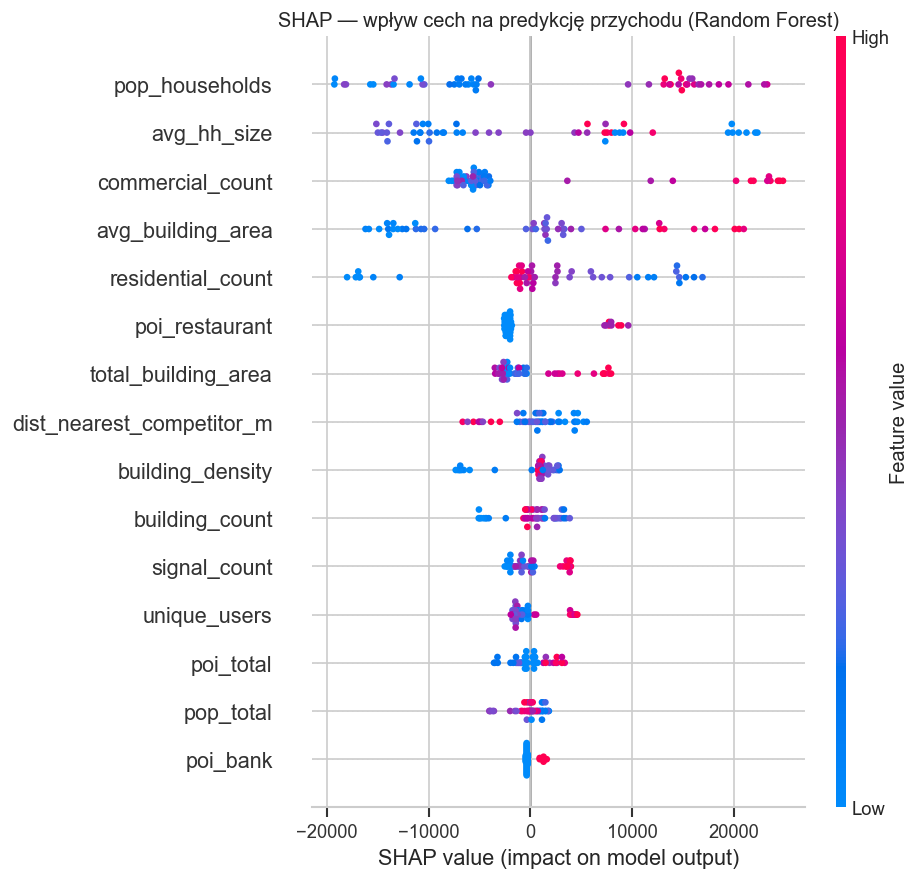

In [7]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, show=False, max_display=15)
plt.title('SHAP — wpływ cech na predykcję przychodu (Random Forest)')
plt.tight_layout()
plt.show()

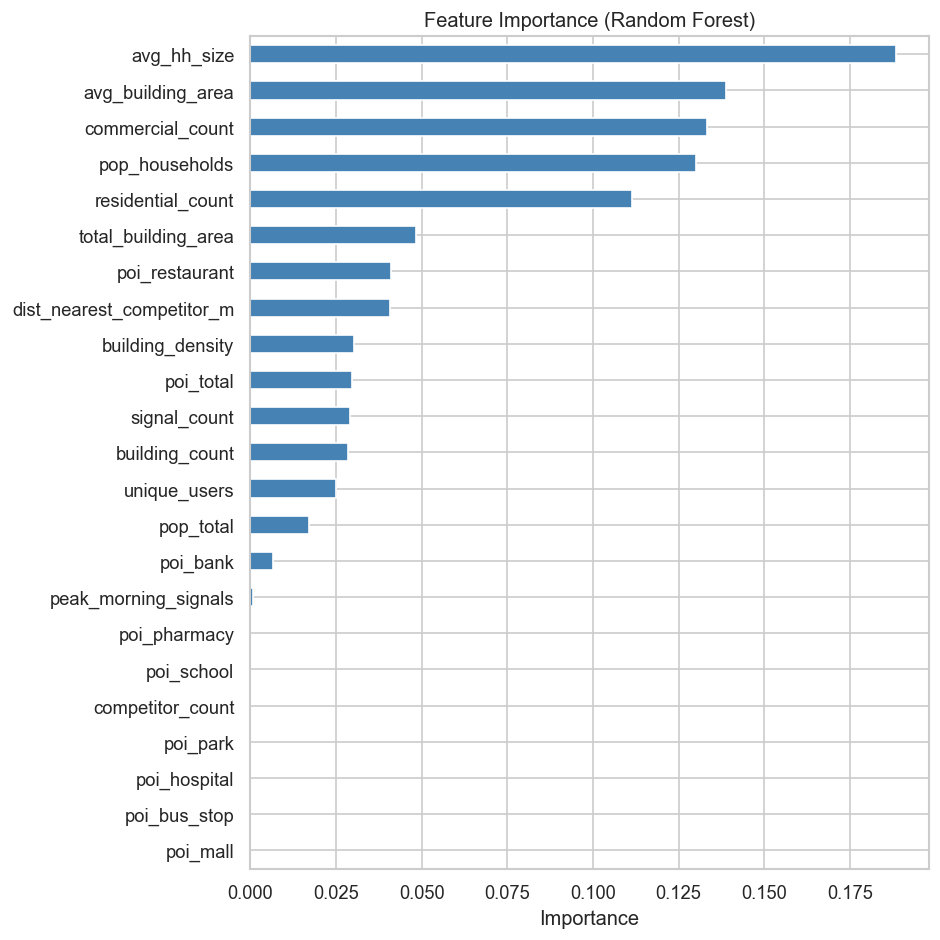

In [8]:
fi = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()